# Generative adversarial networks (GANs)

- Su objetivo es sintetizar nuevos datos, para que parezcan que vienen de la misma distribución del conjunto de entrenamiento.
- ¿Qué tipo de supervisión es?
- Casos de uso
  - Super-resolución
  - Reconstrucción de imágenes
  - Image-to-image translation (style transfer o colorization)
Para entender este tipo de modelos, hay que empezar desde sus fundaciones.

### Autoencoders

- No generan nuevos datos.
- Los "autoencoders" o autocodificador son dos arquitecturas de red concatenadas.
- En la parte del codificador los datos o características se **comprimen** a un espacio llamado "espacio latente", y luego mediante ese vector se reconstruye, mediante un decodificador.
- Tipo de Autoencoder: Denoising autoencoder.
  - Tienen como objetivo entrenar con datos con ruido, y recuperar la característica original.

<center>

![autoencodernn](https://miro.medium.com/v2/resize:fit:1400/0*ETohyQVhOoLiZxdc)

Fuente: https://miro.medium.com/v2/resize:fit:1400/0*ETohyQVhOoLiZxdc

</center>

### Modelos generativos

- Un modelo generativo en estadística se define como un algoritmo que es capaz de modelar la distribución de probabilidad de los datos de entrada.
- Autoencoders son modelos determinísticos, dado que son entrenados solo para regenerar los datos desde el espacio latente y no para generar nuevos datos.
- Un modelo generativo en *deep learning* puede generar un nuevo dato desde un vector en el espacio latente.

## Generar nuevos datos con GANs
- Asumimos que:
  - Existe un vector $z$ muestreado de una distribución de probabilidad de entrada $p(x)$, conocida.
  - Existe una red generadora $G$ capaz de procesar este vector $z$ y genera una salida $\tilde{x} = G(z)$,
  - Existe una función juez que puede medir la calidad de la salida generada. Esto implica que...

<center>

![ganarch](
  https://pub.mdpi-res.com/information/information-14-00575/article_deploy/html/images/information-14-00575-g001.png?1697781602)
Fuente: https://www.mdpi.com/2078-2489/14/10/575

</center>

- En una GAN tenemos a las redes discriminador y generador, que pueden ser entrenadas en simultáneo, y caen en un "juego de adversarios".
  - La red generadora mejora sus salidas
  - La red discriminadora detecta mejor imágenes sintéticas (falsas)

### La función objetivo

- Se maximiza el valor con respecto a la red $D$
- Se minimiza su valor con respecto al generador $G$
- Lo anterior indica que se requieren de dos pasos del optimizador durante en entrenamiento, los que se realizan en forma intercalada:
1. Congelar los pesos de la primera red y optimizar los de la segunda
2. Congelar los pesos de la segunda red y optimizar los de la primera

Sin embargo, en los primeros pasos de entrenamiento de una GAN, como las primeras imágenes son muy ruidosas, la red con alta confianza las discrimina como falsas, y no se produce una optimización para el generador (saturación).

- Discriminador: Las etiquetas son 1 o 0, es decir, real o imagen sintética, por lo que con la función de pérdida Binary Cross Entropy (BCE) se puede entrenar.
- Generador: ¿Etiquetas?
  - Se va a imponer como 1 cuando se calcule la función de pérdida para $G$.

- Pasos básicos para entrenar
  1. Pasar el ejemplo real $x$ a $D$ donde $y=1$.
  2. Pasar el ejemplo falso a $G$ entregando $\tilde{x}$, el cual va a pasar a $D$. Acá, $y = 0$.
  3. Entrenar $D$ utilizando BCE, las respuestas de la red discriminadora ($\hat{y}$) y las etiquetas reales ($y$)
  $D$.
  4. Entrenar $G$ con respuesta de $D$ imponiendo que $y=1$.


In [ ]:
import itertools
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import torchvision
from torchvision import transforms


## Entrenando una DCGAN

In [ ]:
image_path = "./"

# Las imágenes son cargadas mediante PIL así que se debe pasar a tensor.
transform = transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize(mean=(0.5), std=(0.5)),
])

# Cargar el dataset propio de PyTorch
mnist_dataset = torchvision.datasets.MNIST(
  root=image_path, train=True,
  transform=transform, download=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 346kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.25MB/s]


In [ ]:
def make_dcgan_generator_network(input_size, n_filters):
  model = nn.Sequential(
      nn.ConvTranspose2d(input_size, n_filters*4, 4, 1, 0, bias=False), # 1°
      nn.BatchNorm2d(n_filters*4),
      nn.LeakyReLU(0.2),
      nn.ConvTranspose2d(n_filters*4, n_filters*2, 3, 2, 1, bias=False), # 2°
      nn.BatchNorm2d(n_filters*2),
      nn.LeakyReLU(0.2),
      nn.ConvTranspose2d(n_filters*2, n_filters, 4, 2, 1, bias=False), # 3°
      nn.BatchNorm2d(n_filters),
      nn.LeakyReLU(0.2),
      nn.ConvTranspose2d(n_filters, 1, 4, 2, 1, bias=False), # 4°
      nn.Tanh()
  )
  return model

class DiscriminatorDCGAN(nn.Module):
  def __init__(self, n_filters):
    super().__init__()
    self.network = nn.Sequential(
        nn.Conv2d(1, n_filters, 4, 2, 1, bias=False), # 1°
        nn.LeakyReLU(0.2),
        nn.Conv2d(n_filters, n_filters*2, 4, 2, 1, bias=False), # 2°
        nn.BatchNorm2d(n_filters * 2),
        nn.LeakyReLU(0.2),
        nn.Conv2d(n_filters*2, n_filters*4, 3, 2, 1, bias=False), # 3°
        nn.BatchNorm2d(n_filters*4),
        nn.LeakyReLU(0.2),
        nn.Conv2d(n_filters*4, 1, 4, 1, 0, bias=False), # 4°
        nn.Sigmoid()
    )

  def forward(self, x):
    output = self.network(x)
    return output.view(-1, 1).squeeze(0)

# Preparación

torch.manual_seed(1)
np.random.seed(1)

batch_size = 64
n_z = 100 # tamaño del vector en espacio latente
img_size = (28, 28)
n_kernels = 32


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mnist_dataloader = DataLoader(mnist_dataset,
  num_workers=12,
  batch_size=batch_size,
  shuffle=True,
  drop_last=True
)

gen_model_dcgan = make_dcgan_generator_network(n_z, n_kernels).to(device)
print(gen_model_dcgan)

disc_model_dcgan = DiscriminatorDCGAN(n_kernels).to(device)
print(disc_model_dcgan)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Sequential(
  (0): ConvTranspose2d(100, 128, kernel_size=(4, 4), stride=(1, 1), bias=False)
  (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): LeakyReLU(negative_slope=0.2)
  (3): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): LeakyReLU(negative_slope=0.2)
  (6): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (7): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): LeakyReLU(negative_slope=0.2)
  (9): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (10): Tanh()
)
DiscriminatorDCGAN(
  (network): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding

In [ ]:
# Modificar para devolver tensor
def create_noise_tensor(batch_size, n_z, z_mode):
  if z_mode == "uniform":
    z = torch.rand(batch_size, n_z, 1, 1)*2 - 1
  elif z_mode == "normal":
    z = torch.rand(batch_size, n_z, 1, 1)
  return z

In [ ]:
# Criterion
loss_fn = nn.BCELoss()
G_opt_dcgan = torch.optim.Adam(gen_model_dcgan.parameters(), 0.0003)
D_opt_dcgan = torch.optim.Adam(disc_model_dcgan.parameters(), 0.0002)

In [ ]:
def d_train_dcgan(x, loss_fn, disc_model, gen_model, D_opt, latent_space_size, z_distribution_type, device):
  disc_model.zero_grad()

  # Pasada hacia adelante para la imagen real - sin reshape
  batch_size = x.size(0)
  x = x.to(device)
  d_labels_real = torch.ones(batch_size, 1, device=device) # y = 1
  d_prob_real = disc_model(x) # obtener \hat{y}
  d_loss_real = loss_fn(d_prob_real, d_labels_real)


  # Pasada hacia adelante para la imagen sintética
  z = create_noise_tensor(batch_size, latent_space_size, z_distribution_type).to(device)
  g_output = gen_model(z)
  d_prob_synth = disc_model(g_output) # obtener \hat{y}
  d_labels_synth = torch.zeros(batch_size, 1, device=device) # y = 0
  d_loss_synth = loss_fn(d_prob_synth, d_labels_synth)

  # Pérdida final conjunta
  # Backpropagation, se optimizan parámetros de la red discriminadora
  D_loss = d_loss_real + d_loss_synth
  D_loss.backward()
  D_opt.step()
  return D_loss.data.item(), d_prob_real.detach(), d_prob_synth.detach()

def g_train_dcgan(x, loss_fn, gen_model, disc_model, G_opt, latent_space_size,  z_distribution_type, device):
  gen_model.zero_grad()
  batch_size = x.size(0)

  # Samplear un vector desde la distribución de probabilidad del espacio latente
  z = create_noise_tensor(batch_size, latent_space_size, z_distribution_type).to(device)
  # Se obtiene la etiqueta de z, imponiendo que y = 1
  g_labels_real = torch.ones(batch_size, 1, device=device)

  G_out = gen_model(z) # x_tilde = G(z)
  d_prob_synth = disc_model(G_out) # D(x_tilde)

  # Entrenar red generadora mediante backpropagation de la decisión de la red
  # discriminadora
  g_loss = loss_fn(d_prob_synth, g_labels_real)
  g_loss.backward()
  G_opt.step()
  return g_loss.data.item()

def create_samples(g_model, input_z, batch_size, img_size):
  g_output = g_model(input_z)
  images = torch.reshape(g_output, (batch_size, *img_size))
  return (images+1)/2.0

def train_dcgan(epochs, dataloader,
                loss_fn, G_opt, D_opt,
                latent_space_size, z_distribution_type, device):
  fixed_z = create_noise_tensor(batch_size, latent_space_size, z_distribution_type).to(device)
  samples_per_epoch = []
  torch.manual_seed(1)
  for epoch in range(1, epochs+1):
    d_losses, g_losses = [], []
    gen_model_dcgan.train()
    for i, (x, _) in enumerate(dataloader):
      d_loss, d_prob_real, d_prob_synth = d_train_dcgan(x, loss_fn,
                                                        disc_model_dcgan, gen_model_dcgan,
                                                        D_opt,
                                                        latent_space_size, z_distribution_type,
                                                        device)
      d_losses.append(d_loss)
      g_losses.append(g_train_dcgan(x, loss_fn,
                              gen_model_dcgan, disc_model_dcgan,
                              G_opt,
                              latent_space_size,  z_distribution_type,
                              device))
    print(f'Epoch {epoch:03d} | Avg Losses >>'
          f' G/D {torch.FloatTensor(g_losses).mean():.4f}'
          f'/{torch.FloatTensor(d_losses).mean():.4f}')
    gen_model_dcgan.eval()
    samples_per_epoch.append(
        create_samples(gen_model_dcgan, fixed_z, batch_size, img_size).detach().cpu().numpy()
    )

  return samples_per_epoch

samples_per_epoch_dcgan = train_dcgan(100, # epoch
  mnist_dataloader,
  loss_fn, G_opt_dcgan, D_opt_dcgan,
  n_z, "uniform",
  device)

Epoch 001 | Avg Losses >> G/D 4.7036/0.1469
Epoch 002 | Avg Losses >> G/D 3.9430/0.2503
Epoch 003 | Avg Losses >> G/D 3.2054/0.3460
Epoch 004 | Avg Losses >> G/D 3.0011/0.3397
Epoch 005 | Avg Losses >> G/D 2.9878/0.3318
Epoch 006 | Avg Losses >> G/D 2.9270/0.3212
Epoch 007 | Avg Losses >> G/D 3.0007/0.3066
Epoch 008 | Avg Losses >> G/D 3.0651/0.2805
Epoch 009 | Avg Losses >> G/D 3.1158/0.2759
Epoch 010 | Avg Losses >> G/D 3.1805/0.2691
Epoch 011 | Avg Losses >> G/D 3.2800/0.2365
Epoch 012 | Avg Losses >> G/D 3.2590/0.2776
Epoch 013 | Avg Losses >> G/D 3.2775/0.2452
Epoch 014 | Avg Losses >> G/D 3.3929/0.2473
Epoch 015 | Avg Losses >> G/D 3.3673/0.2321
Epoch 016 | Avg Losses >> G/D 3.4068/0.2398
Epoch 017 | Avg Losses >> G/D 3.4923/0.2143
Epoch 018 | Avg Losses >> G/D 3.5146/0.2268
Epoch 019 | Avg Losses >> G/D 3.5666/0.2233
Epoch 020 | Avg Losses >> G/D 3.5555/0.2247
Epoch 021 | Avg Losses >> G/D 3.7145/0.1918
Epoch 022 | Avg Losses >> G/D 3.7018/0.2111
Epoch 023 | Avg Losses >> G/D 3.

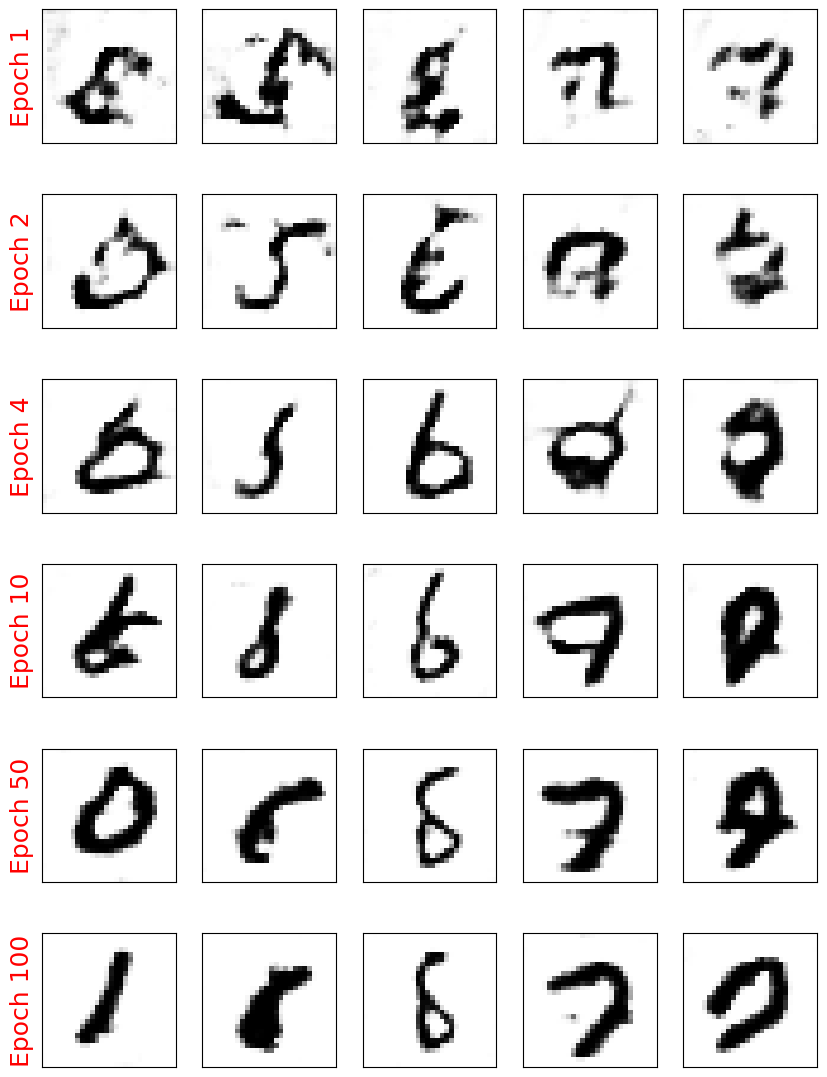

In [ ]:
# Graficar las imágenes creadas por G a través del tiempo
def plot_samples_per_epoch(samples_per_epoch):
  selected_epochs = [1, 2, 4, 10, 50, 100]
  fig = plt.figure(figsize=(10, 14))
  for i, e in enumerate(selected_epochs):
    for j in range(5):
      ax = fig.add_subplot(6, 5, i*5+j+1)
      ax.set_xticks([])
      ax.set_yticks([])
      if j == 0:
        ax.text(
          -0.06, 0.5, f'Epoch {e}',
          rotation=90, size=18, color='red',
          horizontalalignment='right',
          verticalalignment='center',
          transform=ax.transAxes
        )
      image = samples_per_epoch[e - 1][j]
      ax.imshow(image, cmap='gray_r')
  plt.show()

plot_samples_per_epoch(samples_per_epoch_dcgan)

### Referencias

Sebastian Raschka, Yuxi (Hayden) Liu & Vahid Mirjalili. Machine Learning with PyTorch and Scikit-Learn. Ch. 17.

Aurélien Géron. Hands on Machine Learning with Scikit, Keras and Tensorflow. Concepts, Tools and Techniques to Build Intelligent Systems. 2nd ed. Ch 17.